In [29]:
filepath = r'C:\Users\User\Online_retail_analysis\Online_Retail_csv.csv'

import pandas as pd
import numpy as np
df = pd.read_csv(filepath)



In [30]:
clean_df = df[['StockCode','UnitPrice']].dropna()
clean_df = df[df['UnitPrice'] > 0]
stock_prices_dict = dict(zip(clean_df.StockCode, clean_df.UnitPrice))



In [31]:
df['UnitPrice'] = df.StockCode.map(stock_prices_dict)


In [32]:
#prices_above = [i for i in stock_prices_hash.values() if i < 5]
#print(np.mean(prices_above))

#print(len(df.StockCode.unique()))

In [33]:
'''Build the hashmap of stockcode: description where description is all uppercase and len is above 1.
then map it to all other descriptions.
filter out all the descriptions that are not uppercases.
fix those descriptions
ORRRR
since we have fixed prices, do we just find outliers and fix that dataset?
description is not all that important, it is required to gauge which returns are actual returns.
So we can do the following,
1: find ouliers for negative quantities.
2: see if there is a problem with descriptions.'''


'Build the hashmap of stockcode: description where description is all uppercase and len is above 1.\nthen map it to all other descriptions.\nfilter out all the descriptions that are not uppercases.\nfix those descriptions\nORRRR\nsince we have fixed prices, do we just find outliers and fix that dataset?\ndescription is not all that important, it is required to gauge which returns are actual returns.\nSo we can do the following,\n1: find ouliers for negative quantities.\n2: see if there is a problem with descriptions.'

In [34]:
#Fishing_out outliers
def outlier_filter(*series_1) -> tuple:
    '''Finds outlier for numerical Pandas Series of type float and int.
    Returns:
            Tuple(lower_bound, upper_bound) whereby lower bound can be found using oulier_filter('x')[0]
            and upper bound can be found using oulier_filter('x')[1]'''
    upper = np.quantile(series_1, 0.75)
    lower = np.quantile(series_1, 0.25)
    iqr = upper - lower
    lower_bound = lower - 1.5*iqr
    upper_bound = upper + 1.5*iqr
    return (lower_bound, upper_bound)


q1, q2 =  outlier_filter(df.loc[lambda x: x['Quantity'] > 0, ['Quantity']])

print(q1,q2)




-12.5 23.5


In [35]:
clean_description = df[df['Description'].notna() & df['Description'].str.isupper()]
#stock_description_dict_2 = clean_description[clean_description.loc[clean_description['Description'].str.isupper(), ['StockCode', 'Description']]]
stock_description_dict = dict(zip(clean_description.StockCode, clean_description.Description))

df['Description'] = df.StockCode.map(stock_description_dict)
df.info()

errored_df = df[df['Description'].isna()]




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  539530 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541775 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


In [36]:
df['date'] = pd.to_datetime(df.InvoiceDate, errors = 'coerce').dt.date
df['date'] = pd.to_datetime(df['date'], errors = 'coerce')

print(f'minimum is {df['date'].min()}, maximum is {df['date'].max()} ')

neg_quantity = df.loc[lambda x: x['Quantity'] < 0, :]
def validating_false_positive():
    valid_df = df[np.logical_and(df['Quantity'] < 0, df['UnitPrice'] < 0)]
    print(valid_df.shape[0])

validating_false_positive()



minimum is 2010-12-01 00:00:00, maximum is 2011-12-09 00:00:00 
0


In [37]:
df['Revenue'] = (df['Quantity'] * df['UnitPrice']).round(3)

df['Revenue'].describe()
df['Month'] = df['date'].dt.month


months = ['January','February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', \
'October', 'November', 'December']
months_keys = [i for i in range(1,13)]
months_dict = dict(zip(months_keys, months))

df['Month'] = df['date'].dt.month.map(months_dict)
df['Month'] = df.Month.astype('category')
df['Month'] = df['Month'].cat.set_categories(new_categories= months, ordered= True)
print(df.Month)


0         December
1         December
2         December
3         December
4         December
            ...   
541904    December
541905    December
541906    December
541907    December
541908    December
Name: Month, Length: 541909, dtype: category
Categories (12, object): ['January' < 'February' < 'March' < 'April' ... 'September' < 'October' < 'November' < 'December']


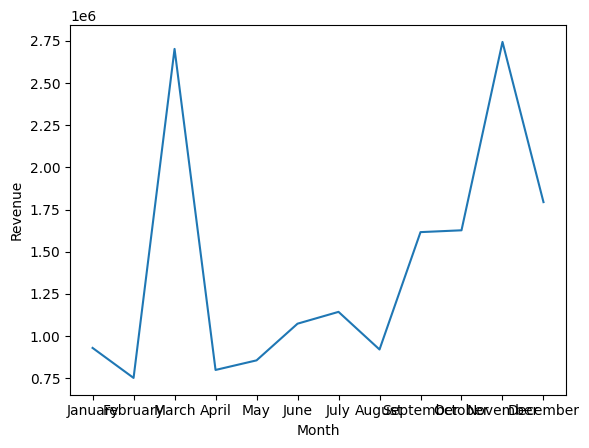

In [38]:
revenue_per_month = df.groupby('Month', observed= False)['Revenue'].sum().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data = revenue_per_month, x= 'Month', y= 'Revenue')
plt.show()


In [39]:
month_revenue = df.groupby('Month', observed= False)['Revenue'].sum().round(2).reset_index()

In [40]:
month_returns_per_country = df.loc[lambda x: x["Quantity"] < 0, :].groupby(['Month', 'Country'], observed= False)['Revenue'].sum().round(2).reset_index()

In [41]:
#purchases no. per country
purchases_per_country = df.Country.value_counts().to_dict()
returns_per_country = df.loc[lambda x: x["Quantity"] < 0, :].groupby(['Country'])['Revenue'].sum().round(2).reset_index()
returns_per_country_2 = df.loc[lambda x: x["Quantity"] < 0, :].groupby(['Country'])['Revenue'].sum().round(2).to_dict()
countries_that_returned = list(returns_per_country.Country)
returns_per_purchases = returns_per_country.loc[lambda x: x['Country'] == countries_that_returned]

returns_per_purchases['UnitsSold'] = returns_per_purchases.Country.map(returns_per_country_2)


"""Reminder to find returns per country ratio. This is also retention rate"""

'Reminder to find returns per country ratio. This is also retention rate'

In [42]:
df.isna().sum()

Unnamed: 0          0
InvoiceNo           0
StockCode           0
Description      2379
Quantity            0
InvoiceDate         0
UnitPrice         134
CustomerID     135080
Country             0
date                0
Revenue           134
Month               0
dtype: int64

In [43]:
empty_prices = df[df.UnitPrice.isna()]
validation_list = []
for key, value in stock_prices_dict.items():
    if key in empty_prices.StockCode:
        validation_list.append(key)

print(len(validation_list))

# Key elements we need here is prices not necessarily description, should I find anomolies with 
# quantity, that is outliers, df.Description analysis will be greatly beneficial to see if these
# were indeed large purchases or large returns and of what good. After that I can keep them
# as there isn't any clear relationship I can see to run a regression analysis.
# Only descriptive analysis can be done here.
# What if I try to find relationship between retention rate and amount of purchases? 
# Write it down on paper tomorrow when power is back. We finish Python scripting tomorrow.

 




0


In [ ]:
df.dropna(subset= 'UnitPrice', inplace = True)



In [ ]:
df.info()




<class 'pandas.core.frame.DataFrame'>
Index: 541775 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Unnamed: 0   541775 non-null  int64         
 1   InvoiceNo    541775 non-null  object        
 2   StockCode    541775 non-null  object        
 3   Description  539529 non-null  object        
 4   Quantity     541775 non-null  int64         
 5   InvoiceDate  541775 non-null  object        
 6   UnitPrice    541775 non-null  float64       
 7   CustomerID   406829 non-null  float64       
 8   Country      541775 non-null  object        
 9   date         541775 non-null  datetime64[ns]
 10  Revenue      541775 non-null  float64       
 11  Month        541775 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(3), int64(2), object(5)
memory usage: 50.1+ MB
